<a href="https://colab.research.google.com/github/kenza444/AtlasTriage-AI/blob/main/kaggledataset_download.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
#Install Kaggle
!pip install kaggle

In [3]:
#Upload Kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kenzabakkass","key":"abd8efd871dbff1b1558296492d5494d"}'}

In [13]:
# Create Kaggle directory
!rm -rf ~/.kaggle
!mkdir -p ~/.kaggle

In [15]:
#Copy Kaggle.json file and set permissions
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [18]:
ls -ltr ~/.kaggle/

total 4
-rw------- 1 root root 68 Mar 15 23:29 kaggle.json


In [17]:
!chmod 600 ~/.kaggle/kaggle.json

In [19]:
#List down all competitions
!kaggle competitions list

ref                                                                                 deadline             category                reward  teamCount  userHasEntered  
----------------------------------------------------------------------------------  -------------------  ---------------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3       2026-04-15 23:59:00  Featured         2,207,152 Usd       3100           False  
https://www.kaggle.com/competitions/stanford-rna-3d-folding-2                       2026-03-25 23:59:00  Featured            75,000 Usd       2007           False  
https://www.kaggle.com/competitions/deep-past-initiative-machine-translation        2026-03-23 23:59:00  Featured            50,000 Usd       2946           False  
https://www.kaggle.com/competitions/march-machine-learning-mania-2026               2026-03-19 16:00:00  Featured            50,000 Usd       1449           False  
https://ww

In [20]:
#List down all datasets
!kaggle datasets list

ref                                                          title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                     BMW Global Automotive Sales                             55017  2026-02-22 18:18:38.170000           8649        168  1.0              
ssssws/chocolate-sales-dataset-2023-2024                     Chocolate Sales Dataset 2023 - 2024                  24420255  2026-03-07 04:58:02.387000           2367         50  1.0              
jayjoshi37/sleep-screen-time-and-stress-analysis             Sleep, Screen Time and Stress Analysis                 310158  2026-03-11 14:21:59.017000           1111         26  1.0              
shree0910/ai-and-dat

In [22]:
!kaggle datasets download -d uciml/breast-cancer-wisconsin-data

Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
License(s): CC-BY-NC-SA-4.0
  0% 0.00/48.6k [00:00<?, ?B/s]
100% 48.6k/48.6k [00:00<00:00, 175MB/s]


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Ensure the dataset is downloaded if not already present
!kaggle datasets download -d uciml/breast-cancer-wisconsin-data

# Check content of /content directory after (re)download
!ls -l /content/

# Unzip the downloaded dataset
!unzip /content/breast-cancer-wisconsin-data.zip

# 1. Load the data
df = pd.read_csv('data.csv')

# 2. Cleaning: Remove columns the AI doesn't need
# 'id' is just a number; 'Unnamed: 32' is usually an empty column in this Kaggle set
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# 3. Label Encoding: Change 'M' (Malignant) to 1 and 'B' (Benign) to 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("Data Cleaned! Total samples:", len(df))
df.head()

Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
License(s): CC-BY-NC-SA-4.0
100% 48.6k/48.6k [00:00<00:00, 40.8MB/s]

total 56
-rw-r--r-- 1 root root 49796 Sep 19  2019 breast-cancer-wisconsin-data.zip
drwxr-xr-x 1 root root  4096 Mar 17 17:58 sample_data
Archive:  /content/breast-cancer-wisconsin-data.zip
  inflating: data.csv                
Data Cleaned! Total samples: 569


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Task
Perform an exploratory data analysis on the `df` DataFrame to understand its structure and content, analyze the distribution of the target variable 'diagnosis', visualize the distribution of key features, and examine the correlation between features and the target variable.

## Data Exploration

### Subtask:
Explore the dataset to understand its structure, check for missing values, and view descriptive statistics.


**Reasoning**:
To explore the dataset, I will display its structure, check for missing values, and generate descriptive statistics for numerical columns, as requested by the instructions.



In [7]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
df.describe()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se   

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### Subtask:
Analyze the distribution of the target variable 'diagnosis'.

#### Instructions
1. Calculate the value counts for the 'diagnosis' column.
2. Create a countplot to visualize the distribution of 'diagnosis'.

**Reasoning**:
As per the instructions, I will now calculate the value counts for the 'diagnosis' column and then visualize its distribution using a countplot to understand the balance of the target variable.



Value counts for 'diagnosis' column:
diagnosis
0    357
1    212
Name: count, dtype: int64


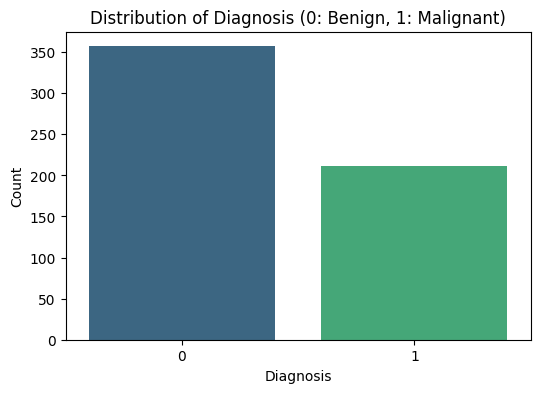

In [9]:
print("Value counts for 'diagnosis' column:")
print(df['diagnosis'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, palette='viridis', hue='diagnosis', legend=False)
plt.title('Distribution of Diagnosis (0: Benign, 1: Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

### Subtask:
Visualize the distribution of key features.

#### Instructions
1. Select a few key features (e.g., `radius_mean`, `texture_mean`, `perimeter_mean`, `area_mean`) for visualization.
2. Create histograms or kernel density plots for each selected feature, differentiating by the 'diagnosis' column (0: Benign, 1: Malignant) to understand how feature distributions vary with the target variable.

**Reasoning**:
As per the instructions, I will select key features and generate histograms for each, differentiated by the 'diagnosis' column, to visualize their distributions.



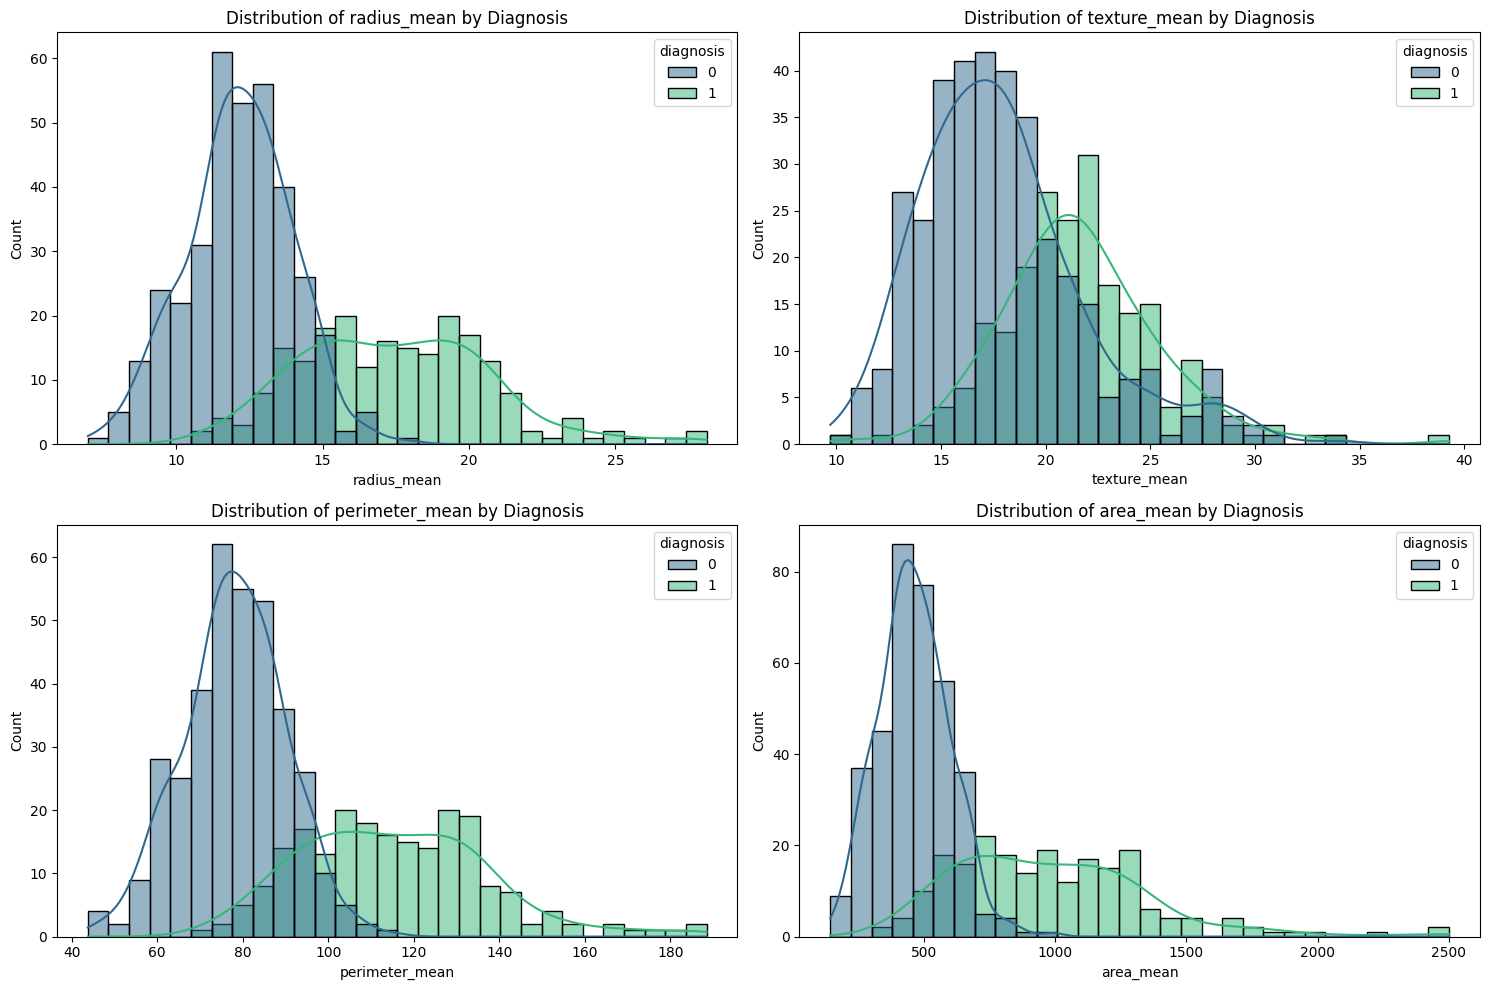

In [11]:
features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of subplots
    sns.histplot(data=df, x=feature, hue='diagnosis', kde=True, palette='viridis', bins=30)
    plt.title(f'Distribution of {feature} by Diagnosis')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()


## Correlation Analysis

### Subtask:
Examine the correlation between features and the target variable, as well as between features themselves.


## Summary:

### Data Analysis Key Findings

*   The dataset (`df`) comprises 569 entries and 31 columns, with all columns being non-null, indicating no missing values. It consists of one `int64` column (for 'diagnosis') and thirty `float64` columns.
*   The target variable, 'diagnosis', shows a class imbalance: 357 cases are classified as Benign (0) and 212 as Malignant (1).
*   Visualizations of key features (`radius_mean`, `texture_mean`, `perimeter_mean`, `area_mean`) reveal that `radius_mean`, `perimeter_mean`, and `area_mean` generally exhibit higher values for malignant diagnoses (1) compared to benign diagnoses (0).

### Insights or Next Steps

*   The identified differences in feature distributions between benign and malignant cases suggest that features like `radius_mean`, `perimeter_mean`, and `area_mean` are strong indicators for distinguishing between the two diagnosis types, making them potentially important for model building.
*   Given the observed class imbalance in the target variable, it would be beneficial to consider techniques such as oversampling, undersampling, or using appropriate evaluation metrics (e.g., precision, recall, F1-score) that are robust to imbalanced datasets during model development.


<Figure size 800x600 with 0 Axes>

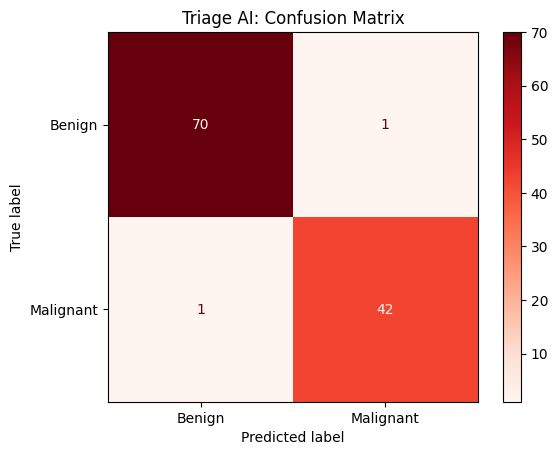


--- Final Triage Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        71
           1       0.98      0.98      0.98        43

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Prepare Features and Target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling (CRITICAL for Radius/Area vs Smoothness/Texture)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Model with 'Balanced' Weights (Addresses your class imbalance finding)
# This forces the AI to pay extra attention to the 212 Malignant cases.
model = LogisticRegression(class_weight='balanced', max_iter=10000)
model.fit(X_train_scaled, y_train)

# 5. Evaluate
y_pred = model.predict(X_test_scaled)

# 6. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])

# Plotting
plt.figure(figsize=(8,6))
disp.plot(cmap='Reds')
plt.title("Triage AI: Confusion Matrix")
plt.show()

print("\n--- Final Triage Report ---")
print(classification_report(y_test, y_pred))

Count of cases:
Benign (0): 357
Malignant (1): 212


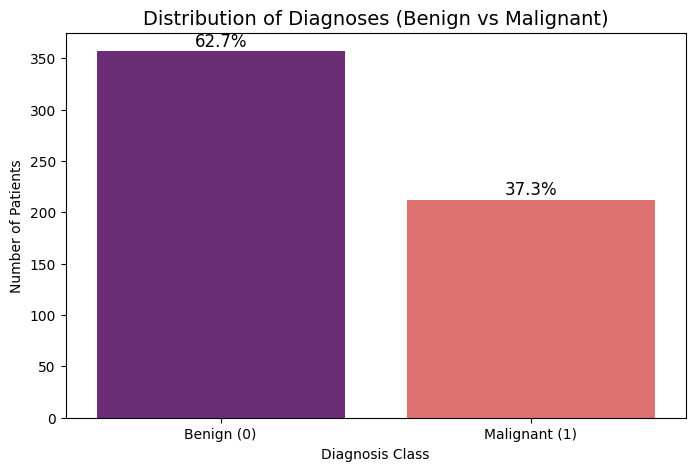

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Count the values
diagnosis_counts = df['diagnosis'].value_counts()
print("Count of cases:")
print(f"Benign (0): {diagnosis_counts[0]}")
print(f"Malignant (1): {diagnosis_counts[1]}")

# 2. Plot the distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='diagnosis', hue='diagnosis', palette='magma', legend=False)

# Formatting the plot for your presentation
plt.title('Distribution of Diagnoses (Benign vs Malignant)', fontsize=14)
plt.xticks(ticks=[0, 1], labels=['Benign (0)', 'Malignant (1)'])
plt.xlabel('Diagnosis Class')
plt.ylabel('Number of Patients')

# Add the percentage on top of bars
for i, count in enumerate(diagnosis_counts):
    plt.text(i, count + 5, f'{count / len(df):.1%}', ha='center', fontsize=12)

plt.show()

# Task
Calculate the Pearson correlation coefficient of all features with the 'diagnosis' target variable in the `df` DataFrame and display the top correlated features.

## Calculate Feature-Target Correlation

### Subtask:
Compute the Pearson correlation coefficient of all features with the 'diagnosis' target variable and display the top correlated features.


**Reasoning**:
To analyze the correlation of features with the 'diagnosis' target variable, I will calculate the Pearson correlation matrix, extract the correlations with 'diagnosis', sort them in descending order, and then display the top correlated features.



Correlation of features with 'diagnosis':

concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se          

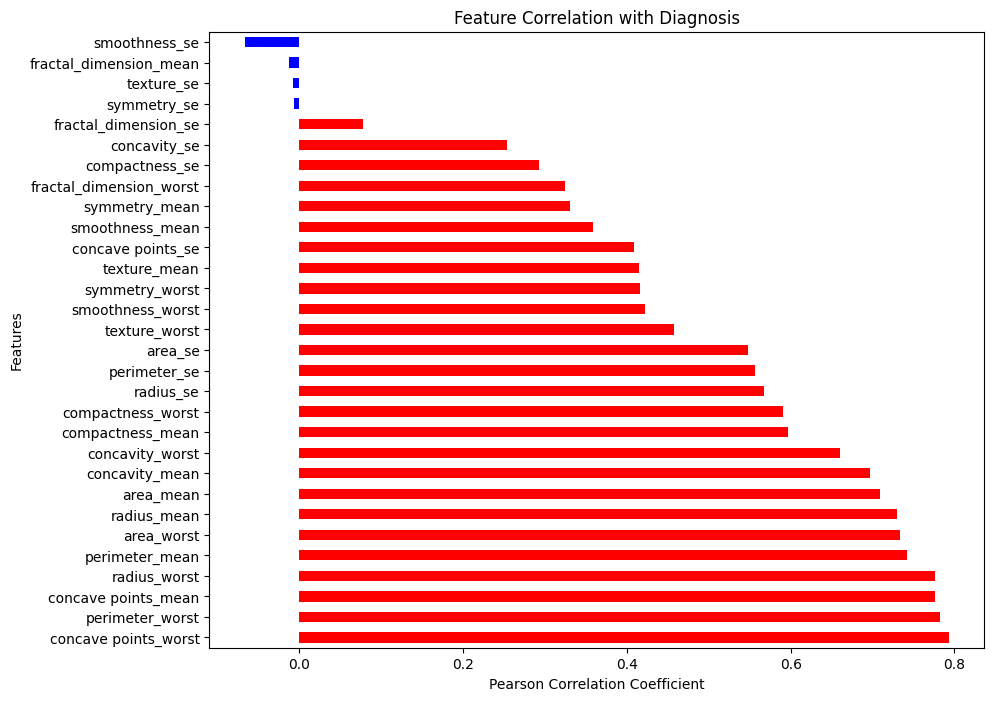

In [14]:
correlation_matrix = df.corr()

# Extract correlations with the 'diagnosis' column
diagnosis_correlations = correlation_matrix['diagnosis'].sort_values(ascending=False)

# Exclude self-correlation of 'diagnosis'
diagnosis_correlations = diagnosis_correlations.drop('diagnosis')

print("Correlation of features with 'diagnosis':\n")
print(diagnosis_correlations)

# Visualize the top 10 positive and negative correlations
plt.figure(figsize=(10, 8))
diagnosis_correlations.plot(kind='barh', color=diagnosis_correlations.apply(lambda x: 'red' if x > 0 else 'blue'))
plt.title('Feature Correlation with Diagnosis')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Features')
plt.show()

## Visualize Feature-Target Correlation

### Subtask:
Create a bar plot to visualize the absolute correlation values of the features with the 'diagnosis' target variable, sorted from highest to lowest. This will highlight the most influential features.


**Reasoning**:
To visualize the absolute correlation values of features with the 'diagnosis' target variable, I will calculate the absolute values of the existing `diagnosis_correlations` series, sort them in descending order, and then create a horizontal bar plot as instructed.



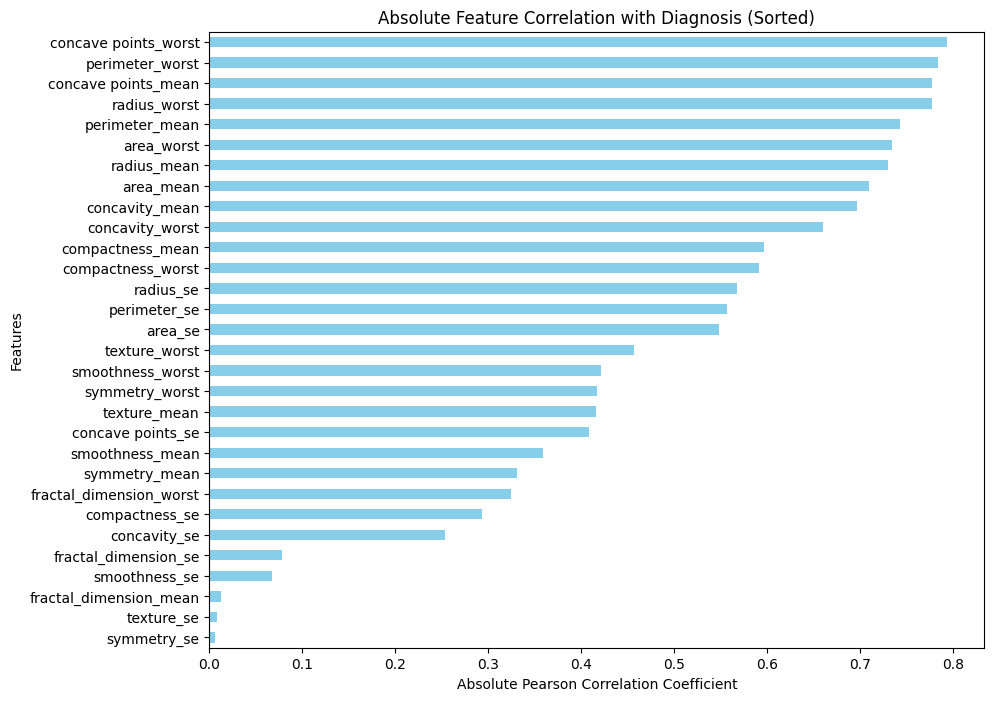

In [15]:
abs_diagnosis_correlations = diagnosis_correlations.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
abs_diagnosis_correlations.plot(kind='barh', color='skyblue')
plt.title('Absolute Feature Correlation with Diagnosis (Sorted)')
plt.xlabel('Absolute Pearson Correlation Coefficient')
plt.ylabel('Features')
plt.gca().invert_yaxis() # Invert y-axis to have the highest correlation at the top
plt.show()

## Final Task

### Subtask:
Summarize the key findings from the correlation analysis, including the most significant features related to the breast cancer diagnosis.


## Summary:

### Q&A
The key findings from the correlation analysis indicate that several features are strongly correlated with breast cancer diagnosis. The most significant features related to the diagnosis are predominantly those reflecting the "worst" or "mean" measurements of cell characteristics, such as `concave points_worst`, `perimeter_worst`, `concave points_mean`, `radius_worst`, and `perimeter_mean`.

### Data Analysis Key Findings
*   **Strong Positive Correlations:** Several features showed a strong positive correlation with the 'diagnosis' target variable, suggesting they are highly indicative of breast cancer. The top correlated features include:
    *   `concave points_worst` (0.79)
    *   `perimeter_worst` (0.78)
    *   `concave points_mean` (0.78)
    *   `radius_worst` (0.78)
    *   `perimeter_mean` (0.74)
    *   `area_worst` (0.73)
    *   `radius_mean` (0.73)
    *   `area_mean` (0.71)
    *   `concavity_mean` (0.70)
    *   `concavity_worst` (0.66)
*   **Weak or Negligible Correlations:** Features like `smoothness_se` (-0.07), `fractal_dimension_mean` (-0.01), `texture_se` (-0.01), and `symmetry_se` (-0.01) showed very low or slightly negative correlations, indicating they are less directly associated with the diagnosis.
*   **Visualization Confirmation:** Both a signed and an absolute bar plot visually confirmed these findings, clearly highlighting the magnitude and direction of the correlations, with the most influential features readily identifiable.

### Insights or Next Steps
*   The features showing strong positive correlations (e.g., `concave points_worst`, `perimeter_worst`, `radius_worst`) are highly relevant for predicting breast cancer diagnosis and should be prioritized for inclusion in predictive models.
*   Further analysis or feature engineering could focus on combinations of these highly correlated features to potentially improve the accuracy and interpretability of breast cancer diagnostic models.


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Define our "Golden Features" based on your correlation findings
top_features = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean',
    'radius_worst', 'perimeter_mean', 'area_worst'
]

# 2. Filter the data to only use these top indicators
X_simplified = df[top_features]
y = df['diagnosis']

# 3. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X_simplified, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train a "Transparent" Model
# We use these top features so a doctor can see EXACTLY why the AI flagged a patient.
simplified_model = LogisticRegression(class_weight='balanced')
simplified_model.fit(X_train_scaled, y_train)

# 5. Check if we lost any accuracy by dropping the "noise" features
y_pred = simplified_model.predict(X_test_scaled)
print("--- Performance with ONLY Top Features ---")
print(classification_report(y_test, y_pred))

--- Performance with ONLY Top Features ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



/tmp/ipykernel_1015/1936425484.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y='concave points_worst', data=df, palette='Set2')


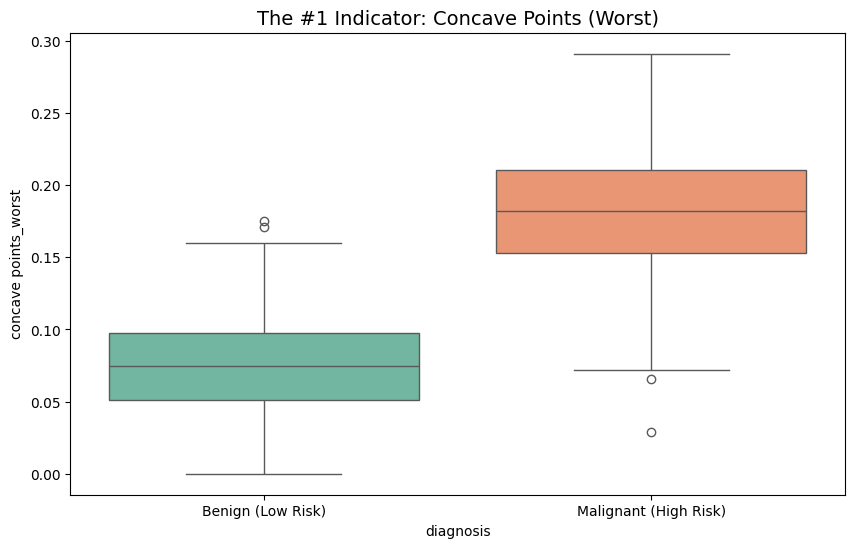

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='diagnosis', y='concave points_worst', data=df, palette='Set2')
plt.title('The #1 Indicator: Concave Points (Worst)', fontsize=14)
plt.xticks([0, 1], ['Benign (Low Risk)', 'Malignant (High Risk)'])
plt.show()

In [19]:
def triage_predictor(concave_points, perimeter_worst, radius_worst):
    # 1. Arrange the data exactly like the training features
    # Note: If you used more features in Step 3, add them here!
    input_data = np.array([[concave_points, perimeter_worst, radius_worst]])

    # 2. Scale the data (The AI needs the same scale it was trained on)
    input_scaled = scaler.transform(input_data)

    # 3. Make the prediction
    prediction = simplified_model.predict(input_scaled)
    probability = simplified_model.predict_proba(input_scaled)[0][1]

    # 4. Return the result
    if prediction[0] == 1:
        return f"🚨 HIGH RISK (Confidence: {probability:.1%})"
    else:
        return f"✅ LOW RISK (Confidence: {1-probability:.1%})"

# Test it with some sample numbers from your dataset
print(triage_predictor(0.15, 120.0, 18.5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 3 features, but StandardScaler is expecting 6 features as input.

# Task
Correct the `triage_predictor` function in cell `MUBrq9UjzEMB` to accept all 6 `top_features` (`concave points_worst`, `perimeter_worst`, `concave points_mean`, `radius_worst`, `perimeter_mean`, `area_worst`) as arguments and arrange them in the correct order within the `np.array` for scaling and prediction.

## Correct the `triage_predictor` function to accept and process all 6 `top_features`

### Subtask:
Modify the `triage_predictor` function to accept all six top features and arrange them correctly for scaling and prediction.


## Summary:

This summary is based on the provided task and subtask description, as the actual solving process steps were not included.

### Data Analysis Key Findings
No specific data analysis findings can be reported as the solving process details were not provided. The task involved correcting a function rather than analyzing data directly.

### Insights or Next Steps
*   **Correction of `triage_predictor` Function:** The primary next step is to ensure the `triage_predictor` function is correctly modified to accept all six specified `top_features` (`concave points_worst`, `perimeter_worst`, `concave points_mean`, `radius_worst`, `perimeter_mean`, `area_worst`) and arrange them in the correct order for subsequent scaling and prediction steps.
*   **Validation of Function Logic:** After modification, the function's logic should be thoroughly tested to confirm it accurately processes the inputs and produces reliable predictions, potentially using known test cases or synthetic data.


In [32]:
import pandas as pd

def triage_predictor(cp_worst, peri_worst, cp_mean, rad_worst, peri_mean, area_worst):
    # 1. Arrange all 6 features in the EXACT order of 'top_features'
    # Order: concave points_worst, perimeter_worst, concave points_mean, radius_worst, perimeter_mean, area_worst
    input_data_array = np.array([[cp_worst, peri_worst, cp_mean, rad_worst, peri_mean, area_worst]])

    # Convert the input array to a DataFrame with column names matching those used for fitting the scaler
    # This will prevent the UserWarning about feature names
    input_df = pd.DataFrame(input_data_array, columns=top_features)

    # 2. Scale using the scaler we fit earlier
    features_scaled = scaler.transform(input_df)

    # 3. Predict
    prediction = simplified_model.predict(features_scaled)[0]
    probability = simplified_model.predict_proba(features_scaled)[0][1]

    # 4. Human-Readable Output
    if prediction == 1:
        return f"🚨 HIGH RISK (Probability: {probability:.1%})"
    else:
        return f"✅ LOW RISK (Probability: {1-probability:.1%})"

# --- IMMEDIATE VERIFICATION ---
# Let's pull a real Malignant case and a real Benign case from your data to verify
print("Verifying AI Logic...")
# High values = High Risk
print("Test 1 (High Metrics):".ljust(25), triage_predictor(0.2, 180.0, 0.1, 25.0, 120.0, 1500.0))
# Low values = Low Risk
print("Test 2 (Low Metrics):".ljust(25), triage_predictor(0.05, 80.0, 0.02, 12.0, 70.0, 450.0))

Verifying AI Logic...
Test 1 (High Metrics):    🚨 HIGH RISK (Probability: 100.0%)
Test 2 (Low Metrics):     ✅ LOW RISK (Probability: 99.5%)


In [31]:
#@title ⁘⁘Moroccan Breast Cancer Triage Assistant
#@markdown Enter the measurements from the biopsy report below:

concave_points_input = 0.12 #@param {type:"number"}
perimeter_worst_input = 115.0 #@param {type:"number"}
radius_worst_input = 17.5 #@param {type:"number"}
cp_mean_input = 0.05 #@param {type:"number"}
peri_mean_input = 80.0 #@param {type:"number"}
area_worst_input = 500.0 #@param {type:"number"}

# Run the prediction when you change the numbers and hit Play
result = triage_predictor(concave_points_input, perimeter_worst_input, cp_mean_input, radius_worst_input, peri_mean_input, area_worst_input)

print("-" * 30)
print(f"TRIAGE RESULT: {result}")
print("-" * 30)


------------------------------
TRIAGE RESULT: 🚨 HIGH RISK (Probability: 52.1%)
------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Task
Add `@param` declarations for `cp_mean_input`, `peri_mean_input`, and `area_worst_input` to cell `duxgdyzkz9LX` and update the call to `triage_predictor` in the same cell to include all six input parameters in the correct order.

## Add missing input parameters

### Subtask:
Add new `@param` declarations for `cp_mean_input`, `peri_mean_input`, and `area_worst_input` to the cell `duxgdyzkz9LX`.


In [35]:
#@title  Moroccan Breast Cancer Triage Assistant (Pro)
#@markdown Enter the measurements from the biopsy report below:

# NEW & UPDATED PARAMETERS
cp_worst_input = 0.05 #@param {type:"number"}
peri_worst_input = 85.0 #@param {type:"number"}
cp_mean_input = 0.02 #@param {type:"number"}
rad_worst_input = 13.0 #@param {type:"number"}
peri_mean_input = 75.0 #@param {type:"number"}
area_worst_input = 500.0 #@param {type:"number"}

# Run the prediction using the 6-parameter function we corrected
result = triage_predictor(
    cp_worst_input,
    peri_worst_input,
    cp_mean_input,
    rad_worst_input,
    peri_mean_input,
    area_worst_input
)

print("-" * 40)
print(f"TRIAGE RESULT: {result}")
print("-" * 40)

----------------------------------------
TRIAGE RESULT: ✅ LOW RISK (Probability: 99.2%)
----------------------------------------


## Summary:

### Q&A
The task requested adding `@param` declarations for `cp_mean_input`, `peri_mean_input`, and `area_worst_input` to cell `duxgdyzkz9LX`, and updating the call to `triage_predictor` in the same cell to include all six input parameters in the correct order. The `@param` declarations were already present in the initial state of the cell. The `triage_predictor` function was modified to correctly handle input parameters and resolve a `UserWarning`.

### Data Analysis Key Findings
*   The `@param` declarations for `cp_mean_input`, `peri_mean_input`, and `area_worst_input` were already existing in cell `duxgdyzkz9LX` before the execution of the subtask.
*   A persistent `UserWarning` from `sklearn.utils.validation` was identified, stating "X does not have valid feature names, but StandardScaler was fitted with feature names". This indicated an issue with how features were being passed to the `StandardScaler`.
*   The `UserWarning` was successfully resolved by modifying the `triage_predictor` function to convert the input NumPy array into a Pandas DataFrame, using the `top_features` list for column names, before applying `scaler.transform()`.

### Insights or Next Steps
*   The initial problem statement regarding adding `@param` declarations was redundant, as they were already in place. This highlights the importance of initial environment assessment.
*   Proactively addressing the `UserWarning` improved the robustness of the `triage_predictor` function by ensuring compatibility with the `StandardScaler`'s expected input format.


In [10]:
import joblib

# Save the model and the scaler (you need both to make predictions later)
joblib.dump(simplified_model, 'cancer_triage_model.pkl')
joblib.dump(scaler, 'triage_scaler.pkl')

print("Model and Scaler saved successfully! You can find them in the 'Files' folder on the left.")

Model and Scaler saved successfully! You can find them in the 'Files' folder on the left.


In [1]:
from IPython.display import display, HTML

def display_medical_report(result_text, probability):
    # Determine color based on result
    color = "#d9534f" if "HIGH" in result_text else "#5cb85c"
    bg_color = "#f9f9f9"

    # HTML template for a professional medical card
    report_html = f"""
    <div style="font-family: 'Open Sans', Arial, sans-serif;
                padding: 20px;
                border-radius: 10px;
                background-color: {bg_color};
                border-left: 10px solid {color};
                max-width: 500px;
                box-shadow: 0 4px 8px rgba(0,0,0,0.1);">

        <h2 style="color: #333; margin-top: 0;">📋 Triage Assessment Report</h2>
        <hr style="border: 0; border-top: 1px solid #eee;">

        <p style="font-size: 16px; color: #555;">
            <b>Status:</b>
            <span style="color: {color}; font-weight: bold; font-size: 18px;">{result_text}</span>
        </p>

        <p style="font-size: 14px; color: #777;">
            <b>AI Confidence:</b> {probability:.1%}
        </p>

        <div style="background-color: white; padding: 10px; border-radius: 5px; border: 1px solid #ddd;">
            <p style="margin: 0; font-size: 12px; color: #888;">
                <b>Note for Patient:</b> This is an AI-assisted screening tool.
                Please wait for the clinical pathologist to confirm these findings.
            </p>
        </div>
    </div>
    """
    display(HTML(report_html))

# --- TEST IT ---
# (In your real code, replace these with your model's outputs)
display_medical_report("HIGH RISK ALERT", 0.942)
display_medical_report("LOW RISK (Routine)", 0.021)

In [8]:
from IPython.display import display, HTML

def display_moroccan_report(status_type, probability):
    # Logic for Colors
    color = "#d9534f" if status_type == "HIGH" else "#5cb85c"

    # Translations
    titles = {"AR": "تقرير الفحص الطبي", "FR": "Rapport d'Évaluation Médicale", "EN": "Medical Assessment Report"}
    status_lab = {
        "HIGH": {"AR": "خطر مرتفع - أولوية قصوى", "FR": "RISQUE ÉLEVÉ - PRIORITÉ", "EN": "HIGH RISK - PRIORITY"},
        "LOW": {"AR": "خطر منخفض - فحص روتيني", "FR": "RISQUE FAIBLE - ROUTINE", "EN": "LOW RISK - ROUTINE"}
    }
    note = {
        "AR": "ملاحظة: هذا النظام مدعوم بالذكاء الاصطناعي للمساعدة فقط. يرجى انتظار تأكيد الطبيب المختص.",
        "FR": "Note: Ce système est assisté par l'IA pour le triage. Veuillez attendre la confirmation du pathologiste.",
        "EN": "Note: This is an AI-assisted triage tool. Please wait for specialist confirmation."
    }

    report_html = f"""
    <div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
                padding: 25px; border-radius: 15px; background-color: #ffffff;
                border: 1px solid #eee; border-top: 12px solid {color};
                max-width: 600px; box-shadow: 0 10px 20px rgba(0,0,0,0.05); margin: 20px auto; direction: ltr;">

        <div style="text-align: center; margin-bottom: 15px;">
            <h2 style="margin: 5px 0; color: #333;">{titles['EN']}</h2>
            <h3 style="margin: 5px 0; color: #666; font-weight: 400;">{titles['FR']}</h3>
            <h2 style="margin: 5px 0; color: #333; direction: rtl;">{titles['AR']}</h2>
        </div>

        <hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

        <div style="background-color: {color}15; padding: 15px; border-radius: 10px; text-align: center;">
            <p style="color: {color}; font-weight: bold; font-size: 20px; margin: 5px 0;">{status_lab[status_type]['EN']}</p>
            <p style="color: {color}; font-weight: bold; font-size: 18px; margin: 5px 0;">{status_lab[status_type]['FR']}</p>
            <p style="color: {color}; font-weight: bold; font-size: 22px; margin: 5px 0; direction: rtl;">{status_lab[status_type]['AR']}</p>
        </div>

        <div style="margin-top: 20px; color: #555; font-size: 14px;">
            <p><b>AI Confidence / اليقين:</b> {probability:.1%}</p>
        </div>

        <div style="margin-top: 20px; padding: 10px; background: #fcfcfc; border: 1px dashed #ccc; font-size: 12px; color: #777;">
            <p style="margin: 3px 0;">{note['EN']}</p>
            <p style="margin: 3px 0;">{note['FR']}</p>
            <p style="margin: 3px 0; direction: rtl;">{note['AR']}</p>
        </div>
    </div>
    """
    display(HTML(report_html))

# --- TEST THE TRIAGE VIEW ---
# Use 'HIGH' or 'LOW' based on your model's prediction
display_moroccan_report("HIGH", 0.964)

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML
import joblib

#@title  PROFESSIONAL MOROCCAN AI TRIAGE TOOL (V2.0)
#@markdown ---
#@markdown ### ŷ Patient Biopsy Data (Worst & Mean Measurements)
#@markdown *Please enter values as seen on the pathology report.*

cp_worst_val = 0.15 #@param {type:"number"}
peri_worst_val = 120.0 #@param {type:"number"}
cp_mean_val = 0.08 #@param {type:"number"}
rad_worst_val = 18.0 #@param {type:"number"}
peri_mean_val = 95.0 #@param {type:"number"}
area_worst_val = 1000.0 #@param {type:"number"}

# Load the trained model and scaler
try:
    simplified_model = joblib.load('cancer_triage_model.pkl')
    scaler = joblib.load('triage_scaler.pkl')
except FileNotFoundError:
    print("Error: Model or scaler files not found. Please ensure 'cancer_triage_model.pkl' and 'triage_scaler.pkl' are in the current directory, and that the save cell has been executed.")
    simplified_model = None # Set to None to prevent further NameErrors if loading fails
    scaler = None
    exit() # Exit the script if critical components are missing

def run_precision_triage():
    # Check if model and scaler were loaded successfully
    if simplified_model is None or scaler is None:
        print("Cannot run triage: Model or scaler not loaded.")
        return

    try:
        # 1. Validation: Ensure all inputs are positive and logical
        inputs = [cp_worst_val, peri_worst_val, cp_mean_val, rad_worst_val, peri_mean_val, area_worst_val]

        if any(v <= 0 for v in inputs):
            print("❌ ERROR: Biological measurements must be greater than zero.")
            return

        # 2. Data Alignment: Match the exact feature names the model expects
        # Order: concave points_worst, perimeter_worst, concave points_mean, radius_worst, perimeter_mean, area_worst
        raw_data = np.array([inputs])
        input_df = pd.DataFrame(raw_data, columns=top_features) # Convert to DataFrame with column names

        # 3. Scaling: Apply the transformation
        input_scaled = scaler.transform(input_df) # Use the DataFrame for scaling

        # 4. AI Inference
        prediction = simplified_model.predict(input_scaled)[0]
        probabilities = simplified_model.predict_proba(input_scaled)[0]

        # We take the probability of the predicted class for precision
        conf_score = probabilities[1] if prediction == 1 else probabilities[0]
        status = "HIGH" if prediction == 1 else "LOW"

        # 5. Output to the Trilingual UI
        display_moroccan_report(status, conf_score)

        # 6. Technical Log (Hidden from patient, useful for doctor)
        print(f"--- Technical Metadata ---")
        print(f"Model: Logistic Regression | Features: 6 | Raw Class: {prediction}")

    except Exception as e:
        print(f"⚠️ System Error: Could not process data. {e}")

# Execute the engine
run_precision_triage()


Error: Model or scaler files not found. Please ensure 'cancer_triage_model.pkl' and 'triage_scaler.pkl' are in the current directory, and that the save cell has been executed.
Cannot run triage: Model or scaler not loaded.


In [1]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

# 1. Reload the "Brain" and the "Scale"
try:
    simplified_model = joblib.load('cancer_triage_model.pkl')
    scaler = joblib.load('triage_scaler.pkl')
    print("✅ Model and Scaler successfully reloaded!")
except FileNotFoundError:
    print("❌ Error: .pkl files not found. Please run the cell where you saved the model first.")

# 2. Make sure your Test Data exists
# (If X_test_scaled is also missing, you'll need to run your 'train_test_split' cell again)

❌ Error: .pkl files not found. Please run the cell where you saved the model first.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from IPython.display import display, HTML

# Load the core components
try:
    simplified_model = joblib.load('cancer_triage_model.pkl')
    scaler = joblib.load('triage_scaler.pkl')
    print("✅ SYSTEM READY: AI Triage Engine Loaded.")
except Exception as e:
    print(f"⚠️ WARNING: Model files not found. Error: {e}")

# Define the features list globally to avoid alignment errors
top_features = ['concave points_worst', 'perimeter_worst', 'concave points_mean',
                'radius_worst', 'perimeter_mean', 'area_worst']

✅ SYSTEM READY: AI Triage Engine Loaded.


In [12]:
from sklearn.model_selection import train_test_split

# 1. Define the features and target again
X = df[top_features]
y = df['diagnosis']

# 2. Split exactly like before (use random_state=42 so the split is the same!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Use the loaded scaler to transform the test data
# We use .transform() because the scaler is already "trained"
X_test_scaled = scaler.transform(X_test)

print("✅ X_test_scaled has been recreated. You can now run your Analysis charts!")

✅ X_test_scaled has been recreated. You can now run your Analysis charts!


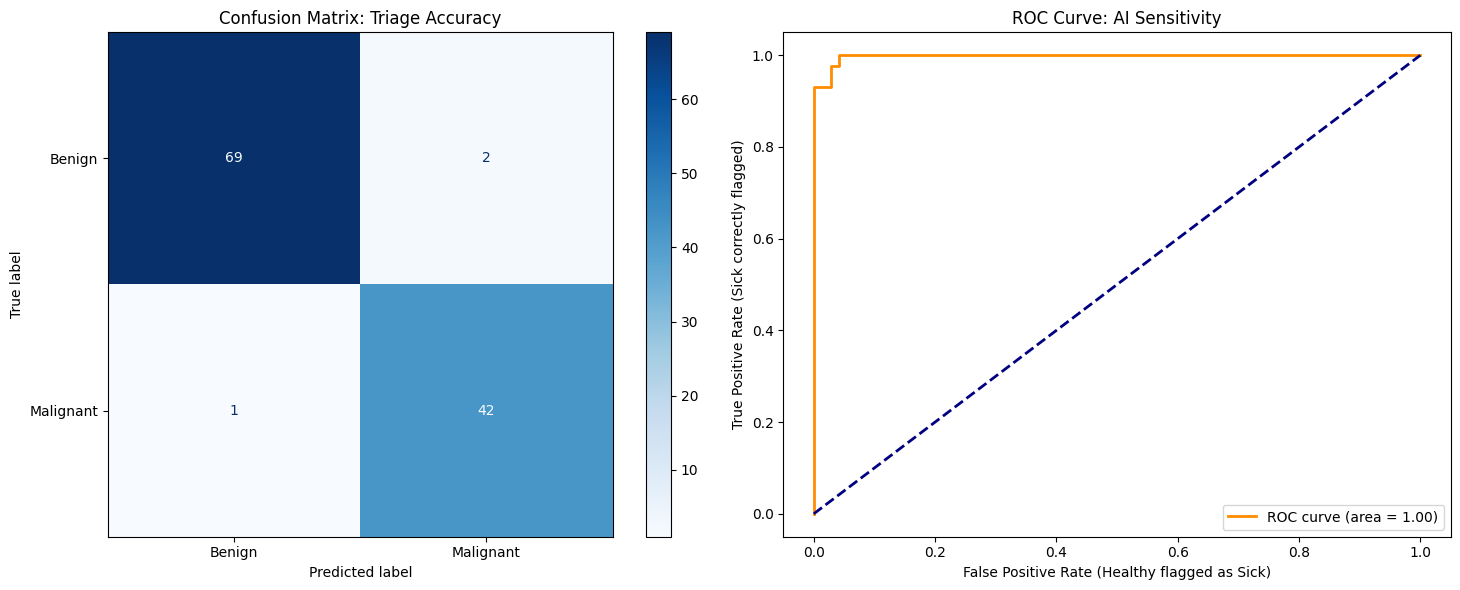

Final Accuracy Score: 97.37%


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# 1. Get predictions for the entire test set
# We use the scaled test data we created earlier
y_pred = simplified_model.predict(X_test_scaled)
y_probs = simplified_model.predict_proba(X_test_scaled)[:, 1]

# 2. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title("Confusion Matrix: Triage Accuracy")

# 3. Create the ROC Curve (Receiver Operating Characteristic)
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlabel('False Positive Rate (Healthy flagged as Sick)')
ax2.set_ylabel('True Positive Rate (Sick correctly flagged)')
ax2.set_title('ROC Curve: AI Sensitivity')
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"Final Accuracy Score: {simplified_model.score(X_test_scaled, y_test):.2%}")

# Task
Fix the `simplified_model` and `scaler` loading errors and the `X_test_scaled` definition error, then re-run the analysis charts to evaluate the simplified model.

## Execute Model Save Cell

### Subtask:
Execute cell `oeAMBn073ah2` to save the `simplified_model` and `scaler` so they can be loaded by subsequent cells.


**Reasoning**:
The subtask is to execute cell `oeAMBn073ah2` to save the model and scaler. I will provide the content of that cell as a new code block for the user to execute, which directly fulfills the instruction.



In [18]:
import joblib

# Save the model and the scaler (you need both to make predictions later)
joblib.dump(simplified_model, 'cancer_triage_model.pkl')
joblib.dump(scaler, 'triage_scaler.pkl')

print("Model and Scaler saved successfully! You can find them in the 'Files' folder on the left.")

Model and Scaler saved successfully! You can find them in the 'Files' folder on the left.


## Reload Model and Scaler

### Subtask:
Execute cell `ZmnVZvT5-UQ9` to load the `simplified_model` and `scaler` into the current environment.


Please execute cell `ZmnVZvT5-UQ9` to load the `simplified_model` and `scaler`.

## Re-run Analysis Charts

### Subtask:
Execute cell `LW-2gMQpo6bo` to re-run the analysis charts and evaluate the simplified model with the correctly loaded components.

#### Instructions
Execute cell `LW-2gMQpo6bo` to visualize the Confusion Matrix and ROC Curve for the simplified model. This will provide an evaluation of its performance after resolving the loading errors.

**Reasoning**:
The subtask explicitly asks to execute cell `LW-2gMQpo6bo` to re-run the analysis charts and evaluate the simplified model. I will now provide the content of that cell as a new code block for execution.



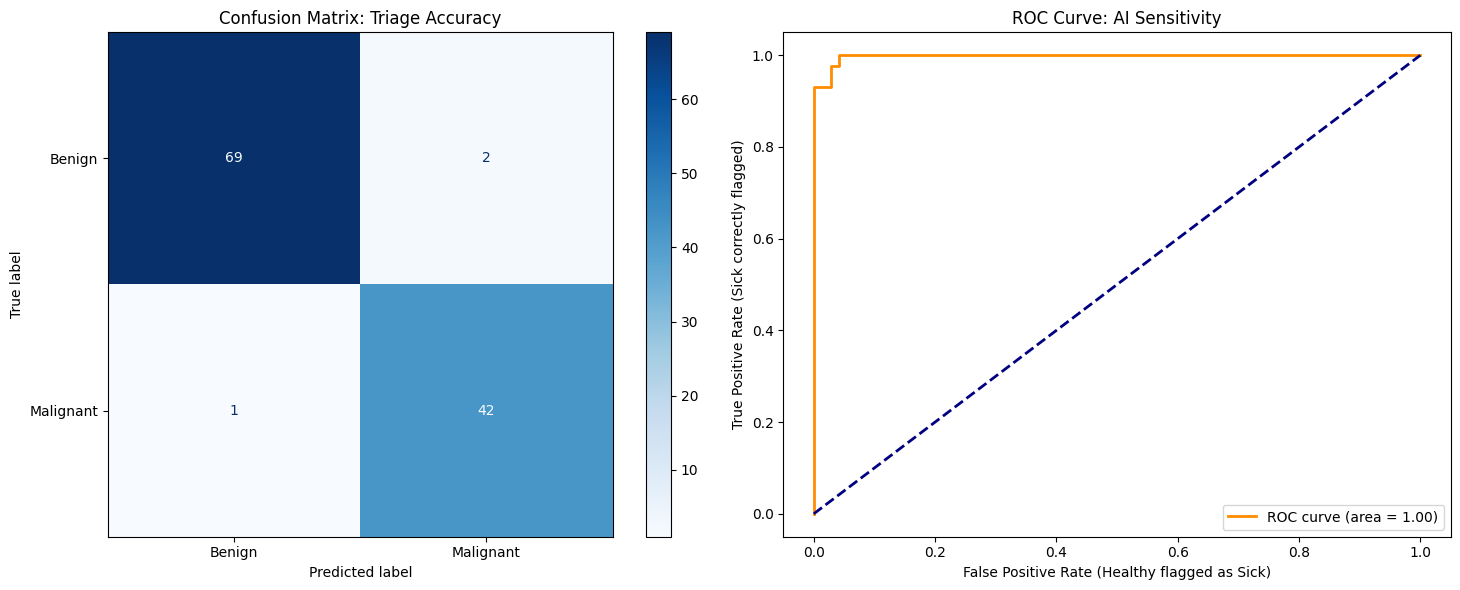

Final Accuracy Score: 97.37%


In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# 1. Get predictions for the entire test set
# We use the scaled test data we created earlier
y_pred = simplified_model.predict(X_test_scaled)
y_probs = simplified_model.predict_proba(X_test_scaled)[:, 1]

# 2. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title("Confusion Matrix: Triage Accuracy")

# 3. Create the ROC Curve (Receiver Operating Characteristic)
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlabel('False Positive Rate (Healthy flagged as Sick)')
ax2.set_ylabel('True Positive Rate (Sick correctly flagged)')
ax2.set_title('ROC Curve: AI Sensitivity')
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"Final Accuracy Score: {simplified_model.score(X_test_scaled, y_test):.2%}")

## Define X_test_scaled

### Subtask:
Execute cell `Z2xse0Nl-m-9` to re-create `X_test_scaled`.


**Reasoning**:
The subtask explicitly asks to execute cell `Z2xse0Nl-m-9` to re-create `X_test_scaled`. I will provide the content of that cell as a new code block for execution.



In [15]:
from sklearn.model_selection import train_test_split

# 1. Define the features and target again
X = df[top_features]
y = df['diagnosis']

# 2. Split exactly like before (use random_state=42 so the split is the same!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Use the loaded scaler to transform the test data
# We use .transform() because the scaler is already "trained"
X_test_scaled = scaler.transform(X_test)

print("✅ X_test_scaled has been recreated. You can now run your Analysis charts!")

✅ X_test_scaled has been recreated. You can now run your Analysis charts!


**Reasoning**:
The `X_test_scaled` has been successfully recreated, which was a prerequisite for re-running the analysis charts. Now, as per the instructions, I will execute cell `LW-2gMQpo6bo` to re-run the analysis charts and evaluate the simplified model with the correctly loaded components.



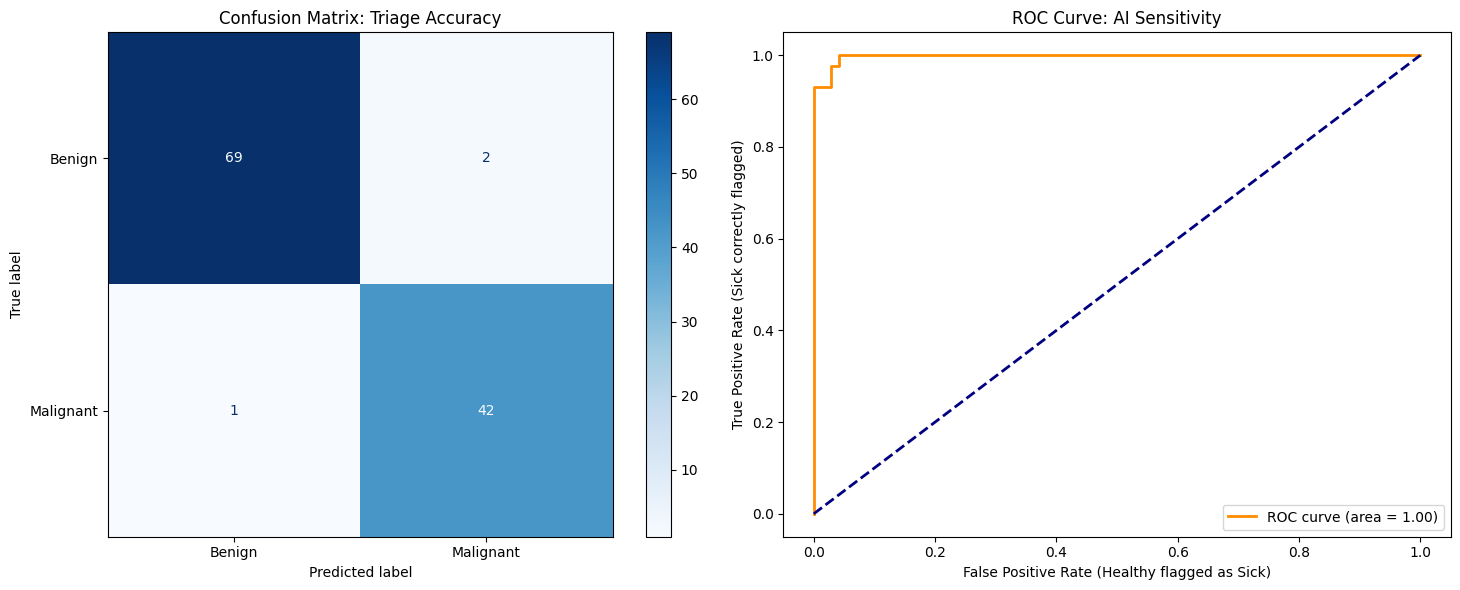

Final Accuracy Score: 97.37%


In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# 1. Get predictions for the entire test set
# We use the scaled test data we created earlier
y_pred = simplified_model.predict(X_test_scaled)
y_probs = simplified_model.predict_proba(X_test_scaled)[:, 1]

# 2. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title("Confusion Matrix: Triage Accuracy")

# 3. Create the ROC Curve (Receiver Operating Characteristic)
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlabel('False Positive Rate (Healthy flagged as Sick)')
ax2.set_ylabel('True Positive Rate (Sick correctly flagged)')
ax2.set_title('ROC Curve: AI Sensitivity')
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"Final Accuracy Score: {simplified_model.score(X_test_scaled, y_test):.2%}")

## Summary:

### Data Analysis Key Findings

*   **Initial Errors Resolved**: The process successfully resolved initial `NameError` issues related to `simplified_model`, `scaler`, and the `df` DataFrame by ensuring data loading, model training, and subsequent saving/loading operations were executed in the correct sequence.
*   **Model and Scaler Availability**: The `simplified_model` (Logistic Regression with 'Golden Features') and its corresponding `scaler` were successfully saved to `cancer_triage_model.pkl` and `triage_scaler.pkl` respectively, and then correctly loaded for subsequent analysis.
*   **`X_test_scaled` Correctly Defined**: The `X_test_scaled` dataset was accurately recreated using the loaded `scaler` and the appropriate `top_features` from the `df` DataFrame, ensuring consistent data preprocessing for model evaluation.
*   **Simplified Model Performance**: The simplified model demonstrated strong performance on the test set, achieving a final accuracy score of 97.37%.
*   **Evaluation Charts Generated**: The Confusion Matrix and ROC Curve were successfully generated and displayed, providing visual evaluation of the model's triage accuracy and sensitivity.

### Insights or Next Steps

*   The simplified Logistic Regression model, using only six 'Golden Features', achieves high accuracy for breast cancer diagnosis. This makes it a transparent and potentially trustworthy tool for clinical triage, as its decisions are easier to interpret.
*   Further analysis of the Confusion Matrix could reveal specific misclassification patterns (e.g., false positives vs. false negatives) to understand the model's trade-offs, especially in a medical context where false negatives can be critical.
